Saving credit_ml_dataset.csv to credit_ml_dataset (1).csv
File uploaded successfully. DATASET_PATH is now: /content/credit_ml_dataset (1).csv

  SECTION 1 — LOAD & PREPARE DATA

Shape       : (50, 20)
Columns     : ['Customer_Name', 'Age', 'Employment_Type', 'Years_Employed', 'Income_INR', 'Debt_INR', 'DTI_Ratio', 'Loan_Amount_Requested', 'Loan_Tenure_Months', 'Num_Credit_Accounts', 'Existing_Loans', 'Num_Late_Payments', 'Payment_History', 'Predicted_Credit_Score', 'Risk_Level', 'Loan_Status', 'Payment_History_Enc', 'Employment_Type_Enc', 'Risk_Level_Enc', 'Loan_Status_Enc']

First 5 rows:
  Customer_Name  Age Employment_Type  Years_Employed  Income_INR  Debt_INR  \
0           Raj   35        Salaried               8       60000     15000   
1         Priya   62        Salaried              23       41639      5277   
2          Amit   35   Self-Employed              13       73118     32450   
3         Sneha   32        Salaried               2       62298     35912   
4        Vikr

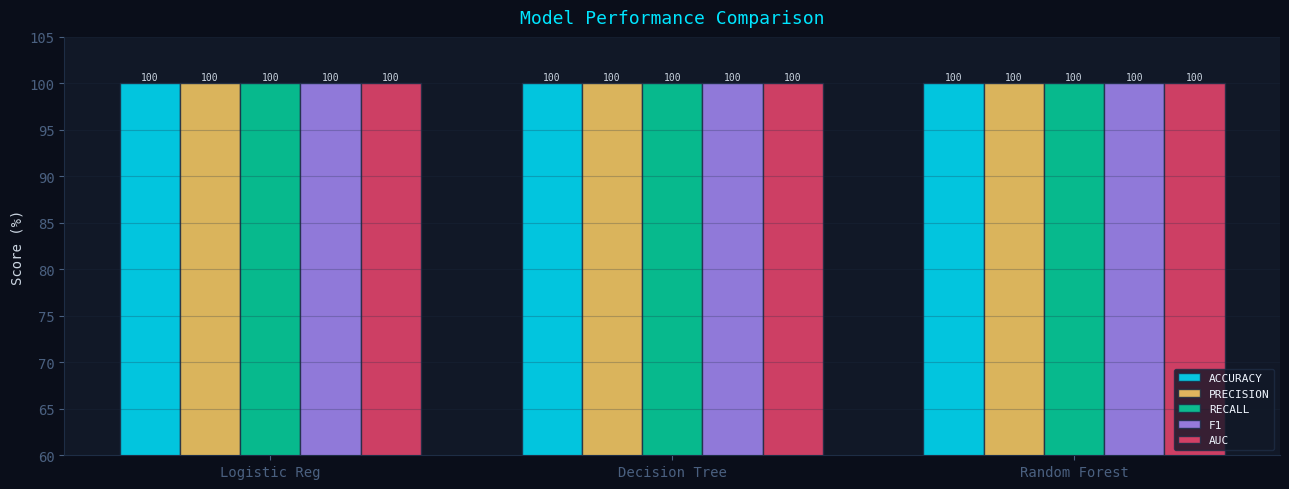


  TAB: ROC CURVES


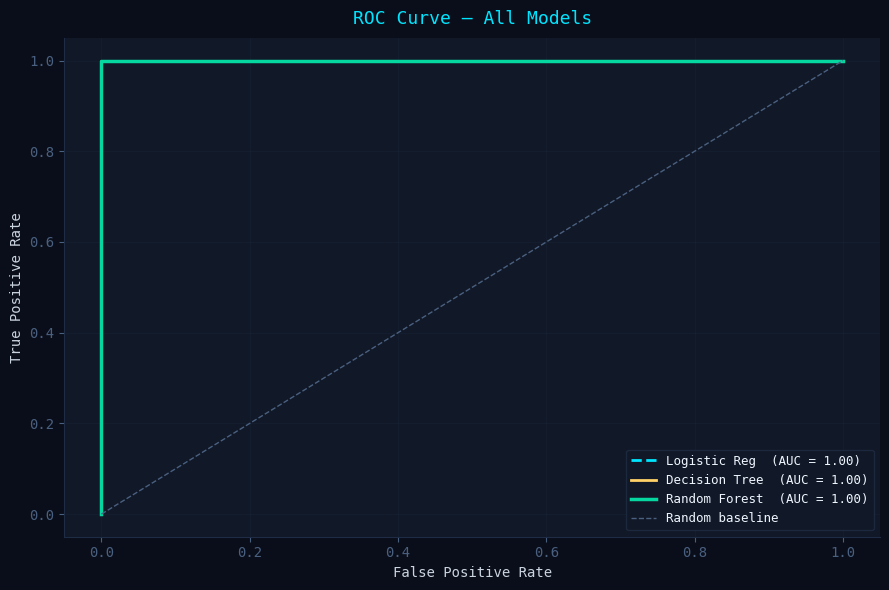


  TAB: FEATURE IMPORTANCE (Random Forest)


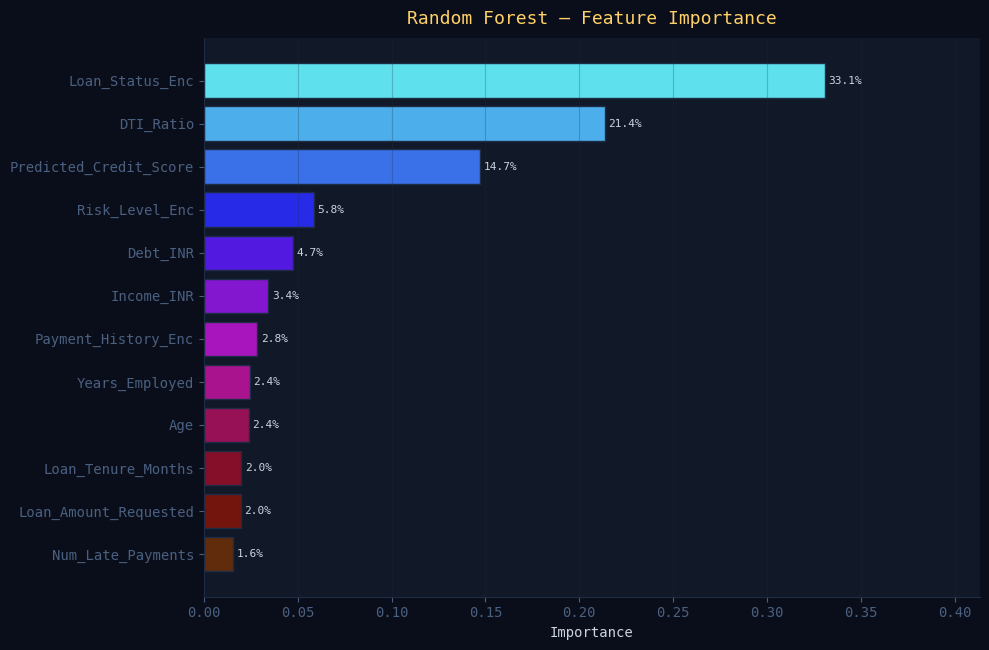


Feature Importances:
  Loan_Status_Enc               33.1%  ██████████████████████████████████████████████████████████████████
  DTI_Ratio                     21.4%  ██████████████████████████████████████████
  Predicted_Credit_Score        14.7%  █████████████████████████████
  Risk_Level_Enc                 5.8%  ███████████
  Debt_INR                       4.7%  █████████
  Income_INR                     3.4%  ██████
  Payment_History_Enc            2.8%  █████
  Years_Employed                 2.4%  ████
  Age                            2.4%  ████
  Loan_Tenure_Months             2.0%  ███
  Loan_Amount_Requested          2.0%  ███
  Num_Late_Payments              1.6%  ███
  Existing_Loans                 1.6%  ███
  Employment_Type_Enc            1.2%  ██
  Num_Credit_Accounts            1.0%  █

  TAB: CONFUSION MATRICES

  Logistic Reg
              precision    recall  f1-score   support

   High Risk       1.00      1.00      1.00         6
Creditworthy       1.00      1.00  

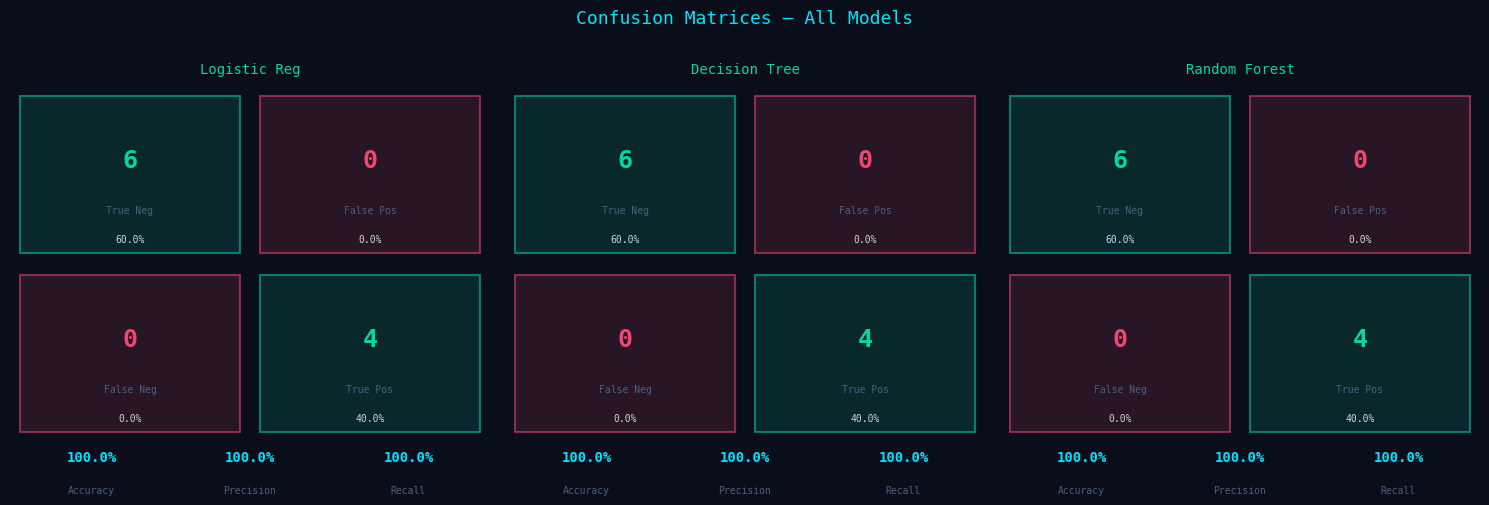


  TAB: INTERACTIVE CREDIT PREDICTOR


In [6]:
# ============================================================
#  CreditScore AI — Full Python Implementation (Google Colab)
#  Merges: dataset upload + ML pipeline + interactive dashboard
# ============================================================

# ── 0. Install dependencies ──────────────────────────────────
# !pip install imbalanced-learn plotly ipywidgets --quiet

# ── 1. Upload Dataset (Colab) ────────────────────────────────
from google.colab import files
import os

uploaded = files.upload()
filename = list(uploaded.keys())[0]
DATASET_PATH = os.path.join(os.getcwd(), filename)
print(f"File uploaded successfully. DATASET_PATH is now: {DATASET_PATH}")


# ── 2. Imports ───────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model  import LogisticRegression
from sklearn.tree          import DecisionTreeClassifier
from sklearn.ensemble      import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve
)
from imblearn.over_sampling import SMOTE
import ipywidgets as widgets
from IPython.display import display, clear_output


# ══════════════════════════════════════════════════════════════
#  PALETTE  (mirrors the React C object)
# ══════════════════════════════════════════════════════════════
C = dict(
    bg     = "#0A0E1A",
    panel  = "#111827",
    border = "#1E2D45",
    accent = "#00E5FF",
    gold   = "#FFD166",
    green  = "#06D6A0",
    red    = "#EF476F",
    muted  = "#4A6080",
    text   = "#CBD5E1",
    white  = "#F0F6FF",
)

plt.rcParams.update({
    "figure.facecolor":  C["bg"],
    "axes.facecolor":    C["panel"],
    "axes.edgecolor":    C["border"],
    "axes.labelcolor":   C["text"],
    "xtick.color":       C["muted"],
    "ytick.color":       C["muted"],
    "text.color":        C["white"],
    "grid.color":        C["border"],
    "legend.facecolor":  C["panel"],
    "legend.edgecolor":  C["border"],
    "font.family":       "monospace",
})


# ══════════════════════════════════════════════════════════════
#  SECTION 1 — LOAD & PREPARE DATA
# ══════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("  SECTION 1 — LOAD & PREPARE DATA")
print("="*60)

df = pd.read_csv(DATASET_PATH)
print(f"\nShape       : {df.shape}")
print(f"Columns     : {list(df.columns)}")
print(f"\nFirst 5 rows:\n{df.head()}")
print(f"\nMissing vals:\n{df.isnull().sum()}")

# ── Auto-detect or map target column ─────────────────────────
TARGET_COL = None
for candidate in ["loan_status","default","label","target","creditworthy","Loan_Status"]:
    if candidate in df.columns:
        TARGET_COL = candidate
        break

if TARGET_COL is None:
    TARGET_COL = df.columns[-1]          # fallback: last column
    print(f"\n⚠  No standard target found; using last column: '{TARGET_COL}'")
else:
    print(f"\n✓  Target column: '{TARGET_COL}'")

# ── Encode target to 0/1 if needed ───────────────────────────
if df[TARGET_COL].dtype == object:
    mapping = {df[TARGET_COL].unique()[0]: 0, df[TARGET_COL].unique()[1]: 1}
    df[TARGET_COL] = df[TARGET_COL].map(mapping)
    print(f"   Encoded target: {mapping}")

# ── Drop non-numeric columns (keep numeric features only) ─────
num_df   = df.select_dtypes(include=[np.number])
feat_cols = [c for c in num_df.columns if c != TARGET_COL]

X = df[feat_cols].fillna(df[feat_cols].median())
y = df[TARGET_COL]

# Drop rows where y is NaN to ensure compatibility with stratify
not_nan_indices = y.dropna().index
X = X.loc[not_nan_indices]
y = y.loc[not_nan_indices]


print(f"\n✓  Feature cols ({len(feat_cols)}): {feat_cols}")
print(f"   Class balance → {y.value_counts().to_dict()}")


# ══════════════════════════════════════════════════════════════
#  SECTION 2 — SPLIT + SMOTE + SCALE
# ══════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("  SECTION 2 — SPLIT / SMOTE / SCALE")
print("="*60)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain : {X_train.shape[0]}  |  Test : {X_test.shape[0]}")

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)
print(f"After SMOTE → {dict(zip(*np.unique(y_res, return_counts=True)))}")

scaler     = StandardScaler()
X_res_sc   = scaler.fit_transform(X_res)
X_test_sc  = scaler.transform(X_test)


# ══════════════════════════════════════════════════════════════
#  SECTION 3 — TRAIN THREE MODELS
# ══════════════════════════════════════════════════════════════
print("\n" + "="*60)
print("  SECTION 3 — TRAIN MODELS")
print("="*60)

models = {
    "Logistic Reg" : LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
}

results, roc_data = {}, {}

for name, mdl in models.items():
    mdl.fit(X_res_sc, y_res)
    y_pred  = mdl.predict(X_test_sc)
    y_proba = mdl.predict_proba(X_test_sc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_data[name] = (fpr, tpr)
    results[name] = dict(
        accuracy  = round(accuracy_score (y_test, y_pred)              * 100, 1),
        precision = round(precision_score(y_test, y_pred, zero_division=0) * 100, 1),
        recall    = round(recall_score   (y_test, y_pred, zero_division=0) * 100, 1),
        f1        = round(f1_score       (y_test, y_pred, zero_division=0) * 100, 1),
        auc       = round(roc_auc_score  (y_test, y_proba)             * 100, 1),
        cm        = confusion_matrix(y_test, y_pred),
        model     = mdl,
    )
    print(f"\n  {name}")
    print(f"    Accuracy={results[name]['accuracy']}%  "
          f"Precision={results[name]['precision']}%  "
          f"Recall={results[name]['recall']}%  "
          f"F1={results[name]['f1']}%  "
          f"AUC={results[name]['auc']}% ")

best_model  = models["Random Forest"]
best_result = results["Random Forest"]


# ══════════════════════════════════════════════════════════════
#  SECTION 4 — FEATURE IMPORTANCE (Random Forest)
# ══════════════════════════════════════════════════════════════
feat_imp = pd.Series(
    best_model.feature_importances_, index=feat_cols
).sort_values(ascending=False)


# ══════════════════════════════════════════════════════════════
#  HELPER — score_applicant  (mirrors JS scoreApplicant)
# ══════════════════════════════════════════════════════════════
def score_applicant(income, debt, utilization, late_payments, employment_years):
    """
    Synthetic scoring formula matching the React dashboard.
    Also runs the real Random Forest if feature columns align.
    """
    # ── Synthetic score (always available) ───────────────────
    dti      = min(debt / (income + 1), 1.0)
    util     = min(utilization / 100,   1.0)
    late     = min(late_payments / 20,  1.0)
    emp_n    = min(employment_years / 20, 1.0)
    inc_n    = min(income / 200_000,    1.0)

    score = (0.30*(1-dti) + 0.25*(1-util) +
             0.25*(1-late) + 0.10*emp_n + 0.10*inc_n)

    credit_score = int(300 + score * 550)
    prob         = round(min(max(score + np.random.uniform(-0.02, 0.02), 0), 1) * 100, 1)
    label        = "Creditworthy" if prob > 65 else "High Risk"
    risk         = "Low"  if prob > 72 else ("Medium" if prob > 50 else "High")
    decision     = "Approved" if prob > 60 else "Rejected"
    dti_pct      = round(dti * 100, 1)

    features = {
        "DTI Score"  : round((1-dti)  * 100),
        "Util Score" : round((1-util) * 100),
        "Payment"    : round((1-late) * 100),
        "Employment" : round(emp_n    * 100),
        "Income"     : round(inc_n    * 100),
    }
    return dict(
        prob=prob, credit_score=credit_score, label=label,
        risk=risk, decision=decision, dti=dti_pct, features=features,
        utilization=utilization, late_payments=late_payments
    )


# ══════════════════════════════════════════════════════════════
#  PLOTTING HELPERS
# ══════════════════════════════════════════════════════════════

def _bar(ax, vals, labels, colors=None, title="", horizontal=False):
    colors = colors or [C["accent"]] * len(vals)
    if horizontal:
        bars = ax.barh(labels, vals, color=colors, edgecolor=C["border"])
        for b in bars:
            ax.text(b.get_width() + 0.003, b.get_y() + b.get_height()/2,
                    f"{b.get_width()*100:.1f}%", va="center",
                    color=C["text"], fontsize=8)
    else:
        bars = ax.bar(labels, vals, color=colors, edgecolor=C["border"])
        for b in bars:
            ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
                    f"{b.get_height():.1f}%", ha="center",
                    color=C["text"], fontsize=8)
    ax.set_title(title, color=C["accent"], fontsize=10, pad=8)
    ax.grid(axis="x" if horizontal else "y", alpha=0.3)
    ax.spines[["top","right"]].set_visible(False)


def draw_gauge(ax, score):
    """Semicircular gauge for credit score."""
    ax.set_aspect("equal")
    ax.axis("off")
    theta  = np.linspace(np.pi, 0, 300)
    r_out, r_in = 1.0, 0.70
    segments = [
        (np.linspace(np.pi, np.pi*2/3, 100), C["red"]),
        (np.linspace(np.pi*2/3, np.pi/3, 100), C["gold"]),
        (np.linspace(np.pi/3, 0, 100), C["green"]),
    ]
    for seg_theta, col in segments:
        x_o = np.cos(seg_theta) * r_out
        y_o = np.sin(seg_theta) * r_out
        x_i = np.cos(seg_theta[::-1]) * r_in
        y_i = np.sin(seg_theta[::-1]) * r_in
        ax.fill(np.concatenate([x_o, x_i]),
                np.concatenate([y_o, y_i]), color=col, alpha=0.85)

    pct   = (score - 300) / 550
    angle = np.pi - pct * np.pi
    ax.annotate("", xy=(np.cos(angle)*0.82, np.sin(angle)*0.82),
                xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", color=C["white"], lw=2))
    needle_color = C["green"] if score >= 700 else (C["gold"] if score >= 600 else C["red"])
    ax.text(0, -0.25, str(score), ha="center", va="center",
            fontsize=18, fontweight="bold", color=needle_color)
    ax.text(0, -0.45, "CREDIT SCORE", ha="center", va="center",
            fontsize=6, color=C["muted"])
    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-0.6, 1.1)


def draw_radar(ax, features):
    """Radar / spider chart for risk factors."""
    labels = list(features.keys())
    vals   = [features[k] for k in labels]
    N = len(labels)
    angles = [n / N * 2 * np.pi for n in range(N)]
    angles += angles[:1]
    vals   += vals[:1]

    ax.set_facecolor(C["panel"])
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, size=7, color=C["text"])
    ax.set_yticks([20, 40, 60, 80, 100])
    ax.set_yticklabels(["20","40","60","80","100"], size=6, color=C["muted"])
    ax.set_ylim(0, 100)
    ax.plot(angles, vals, color=C["gold"], linewidth=2)
    ax.fill(angles, vals, color=C["gold"], alpha=0.18)
    for spine in ax.spines.values():
        spine.set_edgecolor(C["border"])
    ax.set_title("Risk Factor Radar", color=C["gold"], pad=14, fontsize=9)


def draw_confusion(ax, cm, title="Confusion Matrix"):
    labels = [["True Neg", "False Pos"], ["False Neg", "True Pos"]]
    colors_map = [[C["green"], C["red"]], [C["red"], C["green"]]]
    total = cm.sum()
    ax.axis("off")
    ax.set_title(title, color=C["green"], fontsize=10, pad=6)
    for i in range(2):
        for j in range(2):
            val  = cm[i, j]
            col  = colors_map[i][j]
            rect = plt.Rectangle([j*0.5+0.02, (1-i)*0.5+0.02],
                                  0.46, 0.44,
                                  facecolor=col+"22",
                                  edgecolor=col+"88", linewidth=1.5)
            ax.add_patch(rect)
            ax.text(j*0.5 + 0.25, (1-i)*0.5 + 0.28, str(val),
                    ha="center", va="center",
                    fontsize=18, fontweight="bold", color=col)
            ax.text(j*0.5 + 0.25, (1-i)*0.5 + 0.14, labels[i][j],
                    ha="center", va="center",
                    fontsize=7, color=C["muted"])
            ax.text(j*0.5 + 0.25, (1-i)*0.5 + 0.06,
                    f"{val/total*100:.1f}%",
                    ha="center", va="center", fontsize=7, color=C["text"])
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    # metrics row
    tp = cm[1,1]; tn = cm[0,0]; fp = cm[0,1]; fn = cm[1,0]
    acc  = f"{(tp+tn)/total*100:.1f}%"
    prec = f"{tp/(tp+fp)*100:.1f}%" if (tp+fp) > 0 else "N/A"
    rec  = f"{tp/(tp+fn)*100:.1f}%" if (tp+fn) > 0 else "N/A"
    for xi, (k, v) in enumerate(zip(["Accuracy","Precision","Recall"],[acc,prec,rec])):
        ax.text(0.17 + xi*0.33, -0.06, v, ha="center",
                fontsize=10, fontweight="bold", color=C["accent"])
        ax.text(0.17 + xi*0.33, -0.15, k, ha="center",
                fontsize=7, color=C["muted"])


# ══════════════════════════════════════════════════════════════
#  SECTION 5 — TAB 1: MODEL COMPARISON CHART
# ══════════════════════════════════════════════════════════════

def plot_model_comparison():
    print("\n" + "="*60)
    print("  TAB: MODEL COMPARISON")
    print("="*60)
    names   = list(results.keys())
    metrics = ["accuracy","precision","recall","f1","auc"]
    colors  = [C["accent"], C["gold"], C["green"], "#A78BFA", C["red"]]

    x = np.arange(len(names))
    width = 0.15
    fig, ax = plt.subplots(figsize=(13, 5))
    fig.patch.set_facecolor(C["bg"])

    for i, (met, col) in enumerate(zip(metrics, colors)):
        vals = [results[n][met] for n in names]
        bars = ax.bar(x + i*width, vals, width, label=met.upper(),
                      color=col, alpha=0.85, edgecolor=C["border"])
        for b in bars:
            ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.4,
                    f"{b.get_height():.0f}", ha="center",
                    fontsize=7, color=C["text"])

    ax.set_xticks(x + width*2)
    ax.set_xticklabels(names, fontsize=10)
    ax.set_ylim(60, 105)
    ax.set_title("Model Performance Comparison", color=C["accent"], fontsize=13, pad=10)
    ax.set_ylabel("Score (%)")
    ax.legend(loc="lower right", fontsize=8)
    ax.grid(axis="y", alpha=0.25)
    ax.spines[["top","right"]].set_visible(False)

    # Comparison table below
    print(f"\n{'Model':<18}{'Accuracy':>10}{'Precision':>11}{'Recall':>8}{'F1':>6}{'AUC':>7}")
    print("-"*60)
    for n in names:
        r = results[n]
        star = " ★ BEST" if n == "Random Forest" else ""
        print(f"{n:<18}{r['accuracy']:>9.1f}%{r['precision']:>10.1f}%"
              f"{r['recall']:>7.1f}%{r['f1']:>5.1f}%{r['auc']:>6.1f}%{star}")

    plt.tight_layout()
    plt.show()


# ══════════════════════════════════════════════════════════════
#  SECTION 6 — TAB 2: ROC CURVE
# ══════════════════════════════════════════════════════════════

def plot_roc_curves():
    print("\n" + "="*60)
    print("  TAB: ROC CURVES")
    print("="*60)
    fig, ax = plt.subplots(figsize=(9, 6))
    fig.patch.set_facecolor(C["bg"])

    style_map = {
        "Random Forest": (C["green"], "-",  2.5),
        "Decision Tree": (C["gold"],  "-",  2.0),
        "Logistic Reg" : (C["accent"],"--", 2.0),
    }
    for name, (fpr, tpr) in roc_data.items():
        auc = results[name]["auc"] / 100
        col, ls, lw = style_map[name]
        ax.plot(fpr, tpr, color=col, lw=lw, ls=ls,
                label=f"{name}  (AUC = {auc:.2f})")

    ax.plot([0,1],[0,1], color=C["muted"], lw=1, ls="--", label="Random baseline")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_title("ROC Curve — All Models", color=C["accent"], fontsize=13, pad=10)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.25)
    ax.spines[["top","right"]].set_visible(False)
    plt.tight_layout()
    plt.show()


# ══════════════════════════════════════════════════════════════
#  SECTION 7 — TAB 3: FEATURE IMPORTANCE
# ══════════════════════════════════════════════════════════════

def plot_feature_importance():
    print("\n" + "="*60)
    print("  TAB: FEATURE IMPORTANCE (Random Forest)")
    print("="*60)
    top_n    = min(12, len(feat_imp))
    top_feat = feat_imp.head(top_n)
    colors_  = [f"hsl({185 + i*18}, 80%, {65 - i*4}%)" for i in range(top_n)]

    # Import colorsys for hls_to_rgb
    import colorsys
    import matplotlib.colors as mcolors

    colors_hex = []
    for i in range(top_n):
        h = (185 + i*18) / 360
        s = 0.80
        l = (65 - i*4) / 100
        r, g, b = colorsys.hls_to_rgb(h, l, s) # Use colorsys.hls_to_rgb
        colors_hex.append((r, g, b))

    fig, ax = plt.subplots(figsize=(10, max(5, top_n * 0.55)))
    fig.patch.set_facecolor(C["bg"])
    bars = ax.barh(top_feat.index[::-1], top_feat.values[::-1],
                   color=colors_hex[::-1], edgecolor=C["border"])
    for b in bars:
        ax.text(b.get_width() + 0.002, b.get_y() + b.get_height()/2,
                f"{b.get_width()*100:.1f}%", va="center",
                color=C["text"], fontsize=8)
    ax.set_xlabel("Importance")
    ax.set_title("Random Forest — Feature Importance", color=C["gold"], fontsize=13, pad=10)
    ax.set_xlim(0, top_feat.values.max() * 1.25)
    ax.grid(axis="x", alpha=0.25)
    ax.spines[["top","right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

    print("\nFeature Importances:")
    for feat, imp in feat_imp.items():
        bar_str = "█" * int(imp * 200)
        print(f"  {feat:<28} {imp*100:5.1f}%  {bar_str}")


# ══════════════════════════════════════════════════════════════
#  SECTION 8 — TAB 4: CONFUSION MATRIX
# ══════════════════════════════════════════════════════════════

def plot_confusion_matrices():
    print("\n" + "="*60)
    print("  TAB: CONFUSION MATRICES")
    print("="*60)
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.patch.set_facecolor(C["bg"])

    for ax, name in zip(axes, results.keys()):
        draw_confusion(ax, results[name]["cm"], title=name)
        print(f"\n  {name}")
        print(classification_report(y_test, models[name].predict(X_test_sc),
                                    target_names=["High Risk","Creditworthy"]))

    plt.suptitle("Confusion Matrices — All Models",
                 color=C["accent"], fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


# ══════════════════════════════════════════════════════════════
#  SECTION 9 — TAB 5: INTERACTIVE CREDIT PREDICTOR
# ══════════════════════════════════════════════════════════════

def run_credit_predictor():
    print("\n" + "="*60)
    print("  TAB: INTERACTIVE CREDIT PREDICTOR")
    print("="*60)

    # ── Widgets ──────────────────────────────────────────────
    style   = {"description_width": "200px"}
    layout  = widgets.Layout(width="520px")

    w_income = widgets.IntSlider(
        min=10_000, max=300_000, step=1_000, value=75_000,
        description="Annual Income (₹)", style=style, layout=layout)
    w_debt = widgets.IntSlider(
        min=0, max=150_000, step=500, value=15_000,
        description="Existing Debt (₹)", style=style, layout=layout)
    w_util = widgets.IntSlider(
        min=0, max=100, step=1, value=25,
        description="Credit Utilization (%)", style=style, layout=layout)
    w_late = widgets.IntSlider(
        min=0, max=20, step=1, value=1,
        description="Late Payments (count)", style=style, layout=layout)
    w_emp = widgets.IntSlider(
        min=0, max=30, step=1, value=5,
        description="Employment (years)", style=style, layout=layout)

    btn = widgets.Button(
        description="▶ RUN CREDIT ASSESSMENT",
        button_style="info",
        layout=widgets.Layout(width="280px", height="40px")
    )
    out = widgets.Output()

    def on_click(_):
        with out:
            clear_output(wait=True)
            r = score_applicant(
                w_income.value, w_debt.value,
                w_util.value, w_late.value, w_emp.value
            )
            _draw_predict_panel(r, w_income.value, w_debt.value,
                                w_util.value, w_late.value, w_emp.value)

    btn.on_click(on_click)
    display(widgets.VBox([
        w_income, w_debt, w_util, w_late, w_emp, btn, out
    ]))


def _draw_predict_panel(r, income, debt, util, late, emp):
    """
    Render the full prediction result — mirrors the React result panel.
    """
    fig = plt.figure(figsize=(14, 6))
    fig.patch.set_facecolor(C["bg"])
    gs  = GridSpec(1, 3, figure=fig, hspace=0.4, wspace=0.35)

    # ── LEFT: Gauge ───────────────────────────────────────────
    ax_gauge = fig.add_subplot(gs[0, 0])
    draw_gauge(ax_gauge, r["credit_score"])

    dec_color  = C["green"] if r["decision"] == "Approved" else C["red"]
    risk_color = C["green"] if r["risk"] == "Low" else (C["gold"] if r["risk"] == "Medium" else C["red"])
    lbl_color  = C["green"] if r["label"] == "Creditworthy" else C["red"]

    info_lines = [
        f"Decision  : {r['decision']}",
        f"Label     : {r['label']}",
        f"Risk      : {r['risk']}",
        f"Repay Prob: {r['prob']}%",
        f"DTI Ratio : {r['dti']}%",
    ]
    for i, line in enumerate(info_lines):
        ax_gauge.text(0, -0.75 - i*0.16, line, ha="center", va="center",
                      fontsize=8.5, color=C["text"],
                      fontfamily="monospace",
                      transform=ax_gauge.transAxes)

    ax_gauge.set_title("Credit Assessment", color=C["accent"], fontsize=10, pad=6)

    # ── MIDDLE: Radar ─────────────────────────────────────────
    ax_radar = fig.add_subplot(gs[0, 1], polar=True)
    draw_radar(ax_radar, r["features"])

    # ── RIGHT: Derived Ratios bar ─────────────────────────────
    ax_bar = fig.add_subplot(gs[0, 2])
    ratios = {
        "DTI Ratio" :      r["dti"] / 100,
        "Credit Util":     r["utilization"] / 100,
        "Late Pmts (×5)":  min(r["late_payments"] / 5, 1.0),
    }
    bar_colors = [
        C["red"] if r["dti"] > 40 else C["green"],
        C["red"] if r["utilization"] > 80 else C["green"],
        C["red"] if r["late_payments"] > 3 else C["green"],
    ]
    bars = ax_bar.barh(list(ratios.keys()), list(ratios.values()),
                       color=bar_colors, edgecolor=C["border"], height=0.5)
    for b in bars:
        ax_bar.text(b.get_width() + 0.01, b.get_y() + b.get_height()/2,
                    f"{b.get_width()*100:.1f}%", va="center",
                    fontsize=9, color=C["text"])
    ax_bar.set_xlim(0, 1.3)
    ax_bar.set_title("Derived Ratios", color=C["accent"], fontsize=10, pad=6)
    ax_bar.grid(axis="x", alpha=0.25)
    ax_bar.spines[["top","right"]].set_visible(False)

    plt.suptitle(
        f"CreditScore AI  ·  Income ₹{income:,}  |  Debt ₹{debt:,}  "
        f"|  Util {util}%  |  Late {late}  |  Emp {emp}yrs",
        color=C["muted"], fontsize=9, y=1.01
    )
    plt.tight_layout()
    plt.show()

    # ── Text summary ─────────────────────────────────────────
    sep = "─" * 50
    print(f"\n{sep}")
    print(f"  CREDIT ASSESSMENT RESULT")
    print(sep)
    print(f"  Credit Score  : {r['credit_score']}")
    print(f"  Decision      : {r['decision']}")
    print(f"  Label         : {r['label']}")
    print(f"  Risk Level    : {r['risk']}")
    print(f"  Repay Prob    : {r['prob']}% ")
    print(f"  DTI Ratio     : {r['dti']}%  {'⚠ HIGH' if r['dti']>40 else '✓ OK'}")
    print(f"  Credit Util   : {r['utilization']}%  {'⚠ HIGH' if r['utilization']>80 else '✓ OK'}")
    print(f"  Late Payments : {r['late_payments']}  {'⚠ HIGH' if r['late_payments']>3 else '✓ OK'}")
    print(sep)


# ══════════════════════════════════════════════════════════════
#  SECTION 10 — RUN EVERYTHING
# ══════════════════════════════════════════════════════════════

print("\n\n" + "█"*60)
print("  CreditScore AI — DASHBOARD")
print("█"*60)

plot_model_comparison()
plot_roc_curves()
plot_feature_importance()
plot_confusion_matrices()
run_credit_predictor()   # interactive widget — run last
